# EDA · balance del sistema eléctrico peninsular

Réplica, con **datos propios**, de las figuras del informe anual de REE. Complementa a
`02_eda_bronze` (calidad y decisiones de fuente) y a `03_eda_vitaminado` (el target y la
frontera de fuga) con la parte descriptiva que la memoria necesita para **situar el problema**
antes de modelarlo.

## Para qué sirve esto y para qué no

Este notebook es **contexto de la memoria**, no ingeniería de features. Casi todo lo que hay
aquí se calcula con generación y demanda **reales**, así que está del lado equivocado de la
frontera de fuga: sirve para explicar cómo funciona el sistema, no para predecir. Mezclar las
dos cosas es el error que este proyecto lleva evitando desde el principio, y conviene que el
capítulo lo diga explícitamente.

Dicho eso, tres de estas figuras sí alimentan decisiones de modelado y están marcadas como
tales: la penetración renovable por año (L.4), la relación demanda-temperatura (L.9) y el
precio frente a commodities (L.12).

## Diferencia importante con el informe de REE

REE publica series de diez años. **Nuestra base arranca el 1-ene-2020**, así que la evolución
histórica llega hasta donde llega: seis años y medio. No es una limitación que se pueda
disimular estirando el eje — se declara, y punto. Donde REE muestra 2011-2020, aquí se ve
2020-2026, que además es el período interesante: el del despliegue fotovoltaico masivo, la
crisis energética y la excepción ibérica.

## Índice

| Fig. | Contenido | Fuente |
|---|---|---|
| L.1 | Balance de energía por tecnología (GWh) + interconexiones | `entsoe_gen_data`, `load_inter` |
| L.2 | Evolución de la potencia instalada por tecnología | `esios_capacity_installed` |
| L.3 | Estructura de generación por año (%) | generación |
| L.4 | Solar y eólica frente a la demanda total | generación + demanda |
| L.5 | Evolución de la demanda peninsular (TWh/año) | `load_inter` |
| L.6 | Máximos de demanda y perfil horario por estación | `load_inter` |
| L.7 | Renovable vs no renovable (%) por año | generación |
| L.8 | Producción por tecnología y año, separando renovable | generación |
| L.9 | Demanda frente a temperatura: grados-día | `era5` + demanda |
| L.10 | Hidráulica: estacionalidad y comparación con la media | generación |
| L.11 | Coeficiente de utilización de las térmicas | generación + `cap_disp_*` |
| L.12 | Precio frente a commodities | `spot_price` + `commodities` |
| L.13 | Interconexiones: saldo por frontera | `load_inter` |

---
## 0 · Carga y mapa de tecnologías

El problema de un notebook como éste es que cada figura necesita saber qué columna es la
eólica, cuál la nuclear, etc. En vez de escribir los nombres a mano en trece sitios distintos,
se declaran **una vez** en `TECNOLOGIAS`, con una lista de candidatos por tecnología, y todo lo
demás se resuelve solo. Si una columna no aparece, la tecnología se omite con aviso en lugar de
romper la figura entera.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

%matplotlib inline
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

TZ = "Europe/Madrid"
RAIZ = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
BRONZE_DIR = RAIZ / "data" / "bronze"
print("Raíz:", RAIZ, "| bronze existe:", BRONZE_DIR.exists())

plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 12,
})
MILES = FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", "."))

# Períodos de otro régimen -- se marcan, no se promedian con el resto.
APAGON = (pd.Timestamp("2025-04-28", tz="UTC"), pd.Timestamp("2025-05-06 23:00", tz="UTC"))
EXCEPCION = (pd.Timestamp("2022-06-15", tz="UTC"), pd.Timestamp("2023-12-31 23:00", tz="UTC"))

Raíz: c:\Users\torgi\proyectos\tfm-energia | bronze existe: True


In [2]:
# Mapa único de tecnologías: nombre legible -> candidatos de columna, en orden de preferencia.
# Las decisiones ya cerradas del EDA se respetan aquí: calc_solar_fv_mw en vez de ree_gsolar_mw
# (D-03), y el gas de ESIOS separado en vez del B04 de ENTSO-E (D-02).
TECNOLOGIAS = {
    # Nombres REALES de la base (radiografía del 27-ago). Cada entrada acepta la columna de
    # `generation` (prefijo gen_), la del bronce antiguo y la cruda, para que el notebook
    # funcione con cualquiera de las tres versiones del registro.
    # renovables
    "Hidráulica":         (["gen_c_ghydrodispatch", "calc_hydro_dispatch_mw",
                            "entsoe_hydro_reservoir_mw"], "renovable"),
    "Hidráulica fluyente":(["gen_ent_ghydroriver", "entsoe_hydro_run_river_mw"], "renovable"),
    "Eólica":             (["gen_ent_gwind", "entsoe_wind_mw", "esios_gen_ree_gwind_mw"], "renovable"),
    "Solar fotovoltaica": (["gen_c_gsolar", "calc_solar_fv_mw", "entsoe_solar_mw"], "renovable"),
    "Solar térmica":      (["gen_ree_gsolter", "esios_gen_ree_gsolter_mw"], "renovable"),
    "Biomasa":            (["gen_ent_gbiomass"], "renovable"),
    "Residuos":           (["gen_ent_gwaste"], "renovable"),
    "Otras renovables":   (["gen_ent_gotherrenew"], "renovable"),
    # no renovables
    "Nuclear":            (["gen_ree_gnuclear", "entsoe_nuclear_mw"], "no renovable"),
    "Ciclo combinado":    (["gen_ree_gccgt", "esios_gen_ree_gccgas_mw"], "no renovable"),
    "Carbón":             (["gen_ree_gcoal", "esios_gen_ree_gcoal_mw"], "no renovable"),
    "Cogeneración y resto":(["gen_ree_gotherthermal", "esios_gen_ree_gotherthermal_mw"], "no renovable"),
    "Fuel / gasoil":      (["gen_ent_goil"], "no renovable"),
    # almacenamiento
    "Consumo bombeo":     (["gen_ent_cpumping", "entsoe_pumping_cons_mw"], "almacenamiento"),
    "Turbinación bombeo": (["entsoe_pumping_gen_mw"], "almacenamiento"),
    "Batería (entrega)":  (["gen_ree_gbattery", "esios_gen_ree_gbattery_mw"], "almacenamiento"),
    "Batería (carga)":    (["gen_ree_cbattery", "esios_gen_ree_cbattery_mw"], "almacenamiento"),
}

# NOTA sobre la hidráulica: `generation` NO trae el embalse por separado, sino
# `c_ghydrodispatch`, que ya es una derivada (embalse + turbinación de bombeo). El bronce
# calcula la suya, `calc_hydro_dispatch_mw`, y las medias NO coinciden exactamente
# (2.922,41 frente a 2.925,38): hay dos definiciones circulando. Contrastarlas y quedarse
# con una antes de dar por buena cualquier cifra de hidráulica de este notebook.

OMITIDOS = []

def pick(df, *cands):
    for c in cands:
        if c is not None and c in df.columns:
            return c
    return None

def resolver(df, mapa=TECNOLOGIAS):
    '''Devuelve {tecnologia: columna real} solo con las que existen en df.'''
    out, faltan = {}, []
    for nombre, (cands, _fam) in mapa.items():
        c = pick(df, *cands)
        (out.__setitem__(nombre, c) if c else faltan.append(nombre))
    if faltan:
        print("Tecnologías sin columna en este dataframe:", faltan)
        OMITIDOS.append(f"tecnologías sin resolver: {faltan}")
    return out

def familia(nombre):
    return TECNOLOGIAS[nombre][1]

In [3]:
df = pd.read_parquet(BRONZE_DIR / "bronze_unificado.parquet")
df["ts_utc"] = pd.to_datetime(df["ts_utc"], utc=True)

# Guardarraíl: el parquet debe tener una fila por hora. Si falla, es la duplicación x24
# de esios_capacity_available declarada como daily -- corregir el grain antes de seguir.
dup = df["ts_utc"].duplicated().sum()
assert dup == 0, (
    f"{dup:,} filas con ts_utc repetido. Todas las energías de este notebook saldrían "
    f"multiplicadas. Corregir el grain en bronze_config.py y regenerar el parquet."
)

df["ts_local"] = df["ts_utc"].dt.tz_convert(TZ)
df["anio"] = df["ts_local"].dt.year
df["mes"] = df["ts_local"].dt.month
df["dia"] = df["ts_local"].dt.date
df["hora"] = df["ts_local"].dt.hour
print(f"{len(df):,} horas · {df['ts_utc'].min()} -> {df['ts_utc'].max()}")

COLS = resolver(df)
print("\nResueltas:")
for k, v in COLS.items():
    print(f"  {k:24s} -> {v}")

58,319 horas · 2019-12-31 23:00:00+00:00 -> 2026-08-26 21:00:00+00:00
Tecnologías sin columna en este dataframe: ['Biomasa', 'Residuos', 'Otras renovables', 'Nuclear', 'Fuel / gasoil']

Resueltas:
  Hidráulica               -> calc_hydro_dispatch_mw
  Hidráulica fluyente      -> entsoe_hydro_run_river_mw
  Eólica                   -> entsoe_wind_mw
  Solar fotovoltaica       -> calc_solar_fv_mw
  Solar térmica            -> esios_gen_ree_gsolter_mw
  Ciclo combinado          -> esios_gen_ree_gccgas_mw
  Carbón                   -> esios_gen_ree_gcoal_mw
  Cogeneración y resto     -> esios_gen_ree_gotherthermal_mw
  Consumo bombeo           -> entsoe_pumping_cons_mw
  Turbinación bombeo       -> entsoe_pumping_gen_mw
  Batería (entrega)        -> esios_gen_ree_gbattery_mw
  Batería (carga)          -> esios_gen_ree_cbattery_mw


### Nota de método: de MW a GWh

Todas las columnas de generación están en **MW instantáneos** con paso horario. La energía de
un período es por tanto la suma de los MW horarios dividida entre 1.000 (MWh → GWh). Es una
conversión trivial pero conviene dejarla explícita: confundir la media de potencia con la
energía acumulada es el error más común al replicar estas figuras, y produce cifras que no
cuadran con las publicadas por REE.

Los años incompletos (2026 llega hasta agosto) se marcan, porque comparar un año de ocho meses
con uno de doce en un gráfico de barras dice algo falso.

In [4]:
def a_gwh(serie_mw):
    '''MW horarios -> GWh. Los NaN se ignoran (no se imputan: criterio del bronce).'''
    return serie_mw.sum() / 1000

def energia_por(df, agrupador, cols_dict):
    '''Energia en GWh por tecnologia y por el agrupador que se pase (anio, mes, ...).'''
    datos = {}
    for tec, col in cols_dict.items():
        if col:
            datos[tec] = df.groupby(agrupador)[col].sum() / 1000
    return pd.DataFrame(datos)

anios_completos = df.groupby("anio").size().pipe(lambda s: s[s > 8000]).index.tolist()
print("Años con datos completos (>8.000 h):", anios_completos)
print("Años parciales:", [a for a in df['anio'].unique() if a not in anios_completos])

Años con datos completos (>8.000 h): [2020, 2021, 2022, 2023, 2024, 2025]
Años parciales: [np.int32(2026)]


---
## L.1 · Balance de energía por tecnología e interconexiones

**Contexto.** Es la figura de portada del informe de REE: cuánta energía aportó cada tecnología
en el año, cuánto se almacenó y cuál fue el saldo con Francia, Portugal y Marruecos.

**Consecuencia.** Sitúa la escala del problema. Un modelo de precio que ignore que el ciclo
combinado aporta el 16 % de la generación pero marca el precio marginal en muchas más horas
está mirando el mix, no el mercado — y esta figura es la que permite explicar esa diferencia en
la memoria.

In [5]:
ANIO_BALANCE = max(anios_completos) if anios_completos else df["anio"].max()
d = df[df["anio"] == ANIO_BALANCE]

balance = pd.Series({tec: a_gwh(d[col]) for tec, col in COLS.items() if col}).sort_values(ascending=False)
balance_gen = balance[[t for t in balance.index if familia(t) != "almacenamiento"]]

total = balance_gen.sum()
tabla = pd.DataFrame({
    "GWh": balance_gen.round(1),
    "%": (balance_gen / total * 100).round(1),
    "familia": [familia(t) for t in balance_gen.index],
})
print(f"BALANCE {ANIO_BALANCE} · generación total: {total:,.0f} GWh\n")
display(tabla)

print("\nPor familia:")
display(tabla.groupby("familia")["GWh"].sum().round(1).to_frame().assign(
    pct=lambda x: (x["GWh"] / total * 100).round(1)))

BALANCE 2025 · generación total: 202,003 GWh



,GWh,%,familia
Eólica,55458.4,27.5,renovable
Solar fotovoltaica,48767.2,24.1,renovable
Ciclo combinado,38826.0,19.2,no renovable
Hidráulica,30798.8,15.2,renovable
Cogeneración y resto,14859.6,7.4,no renovable
Hidráulica fluyente,8347.9,4.1,renovable
Solar térmica,3624.9,1.8,renovable
Carbón,1319.9,0.7,no renovable



Por familia:


,GWh,pct
familia,,
no renovable,55005.5,27.2
renovable,146997.2,72.8


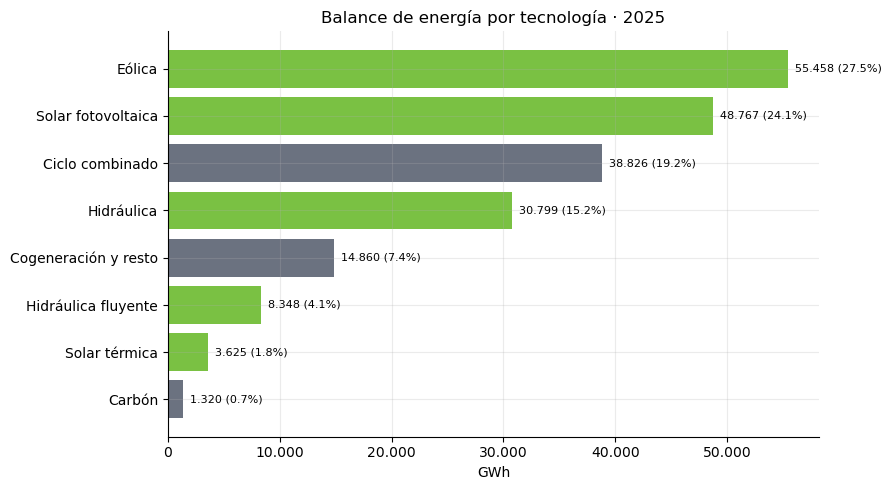

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
colores = {"renovable": "#7ac143", "no renovable": "#6b7280"}
ax.barh(tabla.index[::-1], tabla["GWh"][::-1],
        color=[colores[f] for f in tabla["familia"][::-1]])
ax.set_xlabel("GWh"); ax.xaxis.set_major_formatter(MILES)
ax.set_title(f"Balance de energía por tecnología · {ANIO_BALANCE}")
for i, (v, p) in enumerate(zip(tabla["GWh"][::-1], tabla["%"][::-1])):
    ax.text(v, i, f"  {v:,.0f} ({p}%)".replace(",", "."), va="center", fontsize=8)
plt.tight_layout(); plt.show()

In [7]:
# Almacenamiento y saldo de interconexiones
alm = {t: a_gwh(d[c]) for t, c in COLS.items() if c and familia(t) == "almacenamiento"}
if alm:
    print("ALMACENAMIENTO (GWh):")
    for k, v in alm.items():
        print(f"  {k:22s} {v:>10,.1f}")
    turb = alm.get("Turbinación bombeo", 0)
    cons = alm.get("Consumo bombeo", 0)
    print(f"  {'Saldo bombeo':22s} {turb - cons:>10,.1f}   "
          f"(rendimiento aparente: {turb / cons * 100:.1f}%)" if cons else "")

FRONTERAS = {"Francia": ["load_inter_ree_netflow_fr"], "Portugal": ["load_inter_ree_netflow_pt"],
             "Marruecos": ["load_inter_ree_netflow_ma"], "Andorra": ["load_inter_ree_netflow_ad"]}
saldos = {}
for pais, cands in FRONTERAS.items():
    c = pick(d, *cands)
    if c:
        s = d[c].dropna()
        saldos[pais] = {"importación GWh": a_gwh(s[s > 0]), "exportación GWh": a_gwh(s[s < 0]),
                        "saldo GWh": a_gwh(s)}
if saldos:
    print("\nINTERCONEXIONES (signo positivo = importación):")
    display(pd.DataFrame(saldos).T.round(1))
else:
    print("\nSin columnas de interconexión reconocidas -- revisar nombres en load_inter.")

ALMACENAMIENTO (GWh):
  Consumo bombeo            9,339.4
  Turbinación bombeo        9,059.3
  Batería (entrega)             9.7
  Batería (carga)             -12.1
  Saldo bombeo               -280.1   (rendimiento aparente: 97.0%)

INTERCONEXIONES (signo positivo = importación):


,importación GWh,exportación GWh,saldo GWh
Francia,7272.8,-6873.0,399.8
Portugal,1996.9,-11300.3,-9303.4
Marruecos,167.8,-3920.6,-3752.9


---
## L.2 · Evolución de la potencia instalada

**Contexto.** El equivalente a la figura de estructura de potencia del informe de REE. Aquí
importa más que en el original, porque el crecimiento de la fotovoltaica es **la variable
estructural que explica el cambio de forma del precio horario** que se ve en el bloque F.3.

**Consecuencia.** Si la potencia FV se multiplica en el período de entrenamiento, la relación
entre radiación y precio no es estacionaria: el mismo día soleado produce un efecto distinto en
2020 y en 2026. Es el argumento para ponderar los años recientes o incluir la capacidad
instalada como regresor.

13 de 18 columnas varían en el período. Las constantes son correctas pero inútiles aquí (D-04).


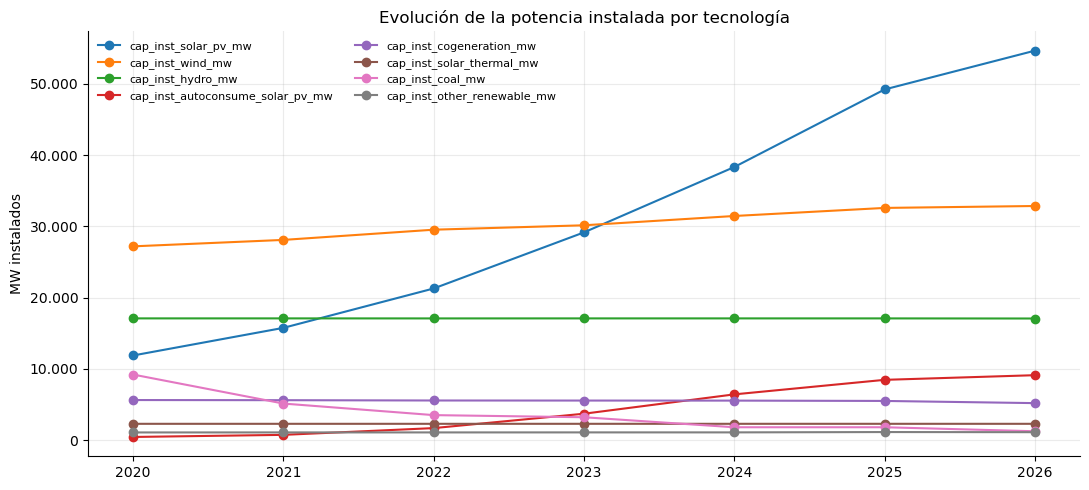

,inicio,final,crecimiento_MW,x veces
cap_inst_solar_pv_mw,11891.0,54668.0,42776.0,5.0
cap_inst_autoconsume_solar_pv_mw,457.0,9125.0,8668.0,20.0
cap_inst_wind_mw,27205.0,32867.0,5662.0,1.0
cap_inst_other_renewable_mw,1091.0,1127.0,36.0,1.0
cap_inst_waste_renewable_mw,119.0,132.0,13.0,1.0
cap_inst_solar_thermal_mw,2302.0,2302.0,-0.0,1.0
cap_inst_hydro_mw,17097.0,17080.0,-18.0,1.0
cap_inst_waste_nonrenewable_mw,404.0,384.0,-20.0,1.0
cap_inst_cogeneration_mw,5638.0,5205.0,-433.0,1.0
cap_inst_coal_mw,9215.0,1258.0,-7957.0,0.0


In [8]:
cap_inst = [c for c in df.columns if c.startswith("cap_inst_")]
if not cap_inst:
    OMITIDOS.append("L.2: faltan las columnas cap_inst_* (esios_capacity_installed)")
    print("OMITIDO -- no hay cap_inst_* en el bronce. Añadir esios_capacity_installed.")
else:
    evol = df.groupby("anio")[cap_inst].max().dropna(how="all")
    # Sólo las que se mueven: las constantes (D-04) no aportan a una figura de evolución.
    mueven = evol.columns[evol.nunique() > 1]
    print(f"{len(mueven)} de {len(cap_inst)} columnas varían en el período. "
          f"Las constantes son correctas pero inútiles aquí (D-04).")

    top = evol[mueven].iloc[-1].sort_values(ascending=False).head(8).index
    ax = evol[top].plot(marker="o", figsize=(11, 5))
    ax.set_ylabel("MW instalados"); ax.set_xlabel("")
    ax.yaxis.set_major_formatter(MILES)
    ax.set_title("Evolución de la potencia instalada por tecnología")
    ax.legend(frameon=False, fontsize=8, ncol=2)
    plt.tight_layout(); plt.show()

    crec = pd.DataFrame({
        "inicio": evol[mueven].iloc[0], "final": evol[mueven].iloc[-1],
    })
    crec["crecimiento_MW"] = crec["final"] - crec["inicio"]
    crec["x veces"] = (crec["final"] / crec["inicio"].replace(0, np.nan)).round(1)
    display(crec.sort_values("crecimiento_MW", ascending=False).round(0))

---
## L.3 · Estructura de generación por año

**Contexto.** Cómo cambia el reparto del mix a lo largo del período. En el informe de REE es un
par de donuts; en serie temporal dice bastante más.

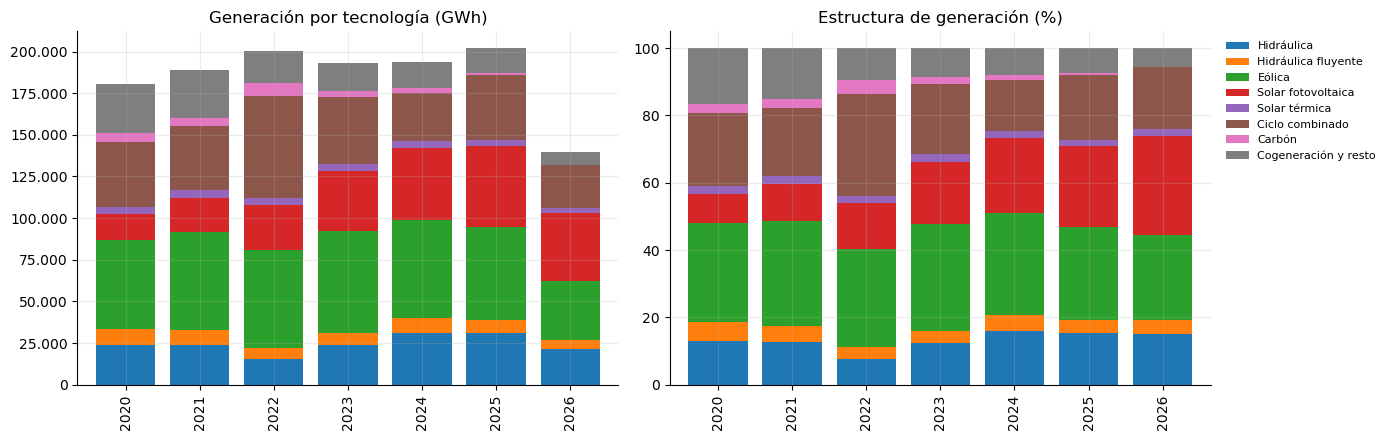

Aviso: los años parciales (2026 hasta agosto) tienen menos GWh por definición. El panel de porcentajes sí es comparable entre años; el de GWh, no.


,Hidráulica,Hidráulica fluyente,Eólica,Solar fotovoltaica,Solar térmica,Ciclo combinado,Carbón,Cogeneración y resto
anio,,,,,,,,
2020,13.1,5.6,29.4,8.6,2.5,21.5,2.8,16.5
2021,12.8,4.5,31.3,10.9,2.5,20.2,2.7,15.0
2022,7.7,3.4,29.4,13.5,2.0,30.4,4.0,9.6
2023,12.4,3.7,31.6,18.5,2.4,20.6,2.0,8.7
2024,16.1,4.6,30.5,22.3,2.1,15.0,1.5,7.9
2025,15.2,4.1,27.5,24.1,1.8,19.2,0.7,7.4
2026,15.2,4.2,25.1,29.4,2.2,18.4,0.1,5.5


In [9]:
cols_gen = {t: c for t, c in COLS.items() if c and familia(t) != "almacenamiento"}
E = energia_por(df, "anio", cols_gen)
E_pct = E.div(E.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
E.plot(kind="bar", stacked=True, ax=axes[0], width=0.8)
axes[0].set_title("Generación por tecnología (GWh)"); axes[0].set_xlabel("")
axes[0].yaxis.set_major_formatter(MILES)
axes[0].legend().remove()

E_pct.plot(kind="bar", stacked=True, ax=axes[1], width=0.8)
axes[1].set_title("Estructura de generación (%)"); axes[1].set_xlabel("")
axes[1].legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

print("Aviso: los años parciales (2026 hasta agosto) tienen menos GWh por definición. "
      "El panel de porcentajes sí es comparable entre años; el de GWh, no.")
display(E_pct.round(1))

## L.4 · Penetración de solar y eólica frente a la demanda

**Contexto.** La pregunta que de verdad importa para el precio no es cuánta renovable hay, sino
**qué fracción de la demanda cubre** — porque es esa fracción la que empuja el precio a cero.

**Consecuencia (feature).** Esta figura sí alimenta el modelado: la penetración renovable
prevista, construida sólo con previsiones, es la versión sin fuga del driver que mejor explica
las horas de precio bajo. Ver `calc_demanda_residual_prev_mw` en el patch de configuración.

C:\Users\torgi\AppData\Local\Temp\ipykernel_16072\1595862556.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  m["mes_p"] = m["ts_local"].dt.to_period("M")


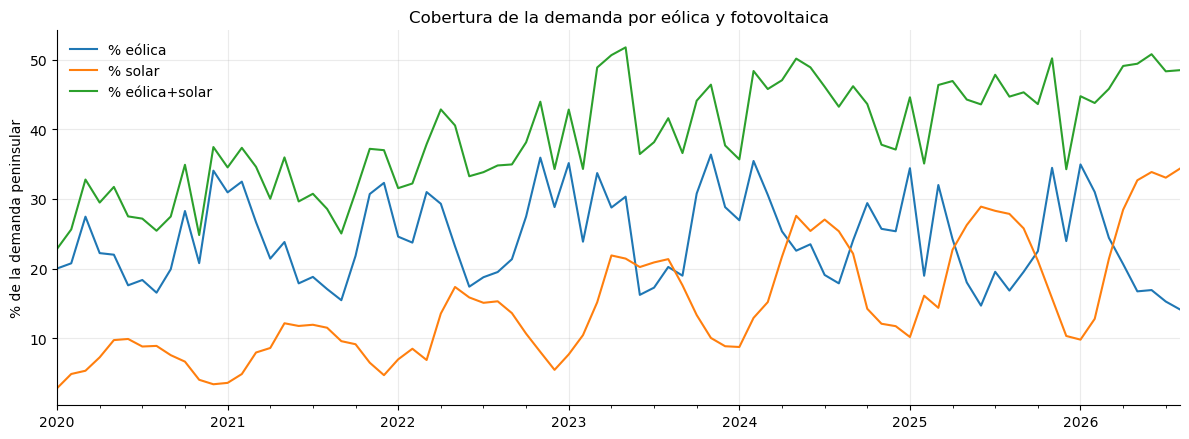

,% eólica,% solar,% eólica+solar
mes_p,,,
2020,22.3,6.6,28.9
2021,24.1,8.5,32.6
2022,25.1,11.4,36.5
2023,26.7,15.7,42.4
2024,25.5,18.7,44.2
2025,23.3,20.6,43.9
2026,21.8,25.8,47.5



El salto de la fila '% solar' entre el primer y el último año es la magnitud del cambio estructural que el modelo tiene que absorber.


In [10]:
dem = pick(df, "load_inter_entsoe_load", "ent_li_actual_load_mw", "load_inter_ree_load")
eol, fv = COLS.get("Eólica"), COLS.get("Solar fotovoltaica")
if not all([dem, eol, fv]):
    OMITIDOS.append("L.4: falta demanda, eólica o solar")
    print("OMITIDO --", {"demanda": dem, "eólica": eol, "solar": fv})
else:
    m = df.copy()
    m["mes_p"] = m["ts_local"].dt.to_period("M")
    agg = m.groupby("mes_p").agg(demanda=(dem, "sum"), eolica=(eol, "sum"), solar=(fv, "sum")) / 1000
    agg["% eólica"] = agg["eolica"] / agg["demanda"] * 100
    agg["% solar"] = agg["solar"] / agg["demanda"] * 100
    agg["% eólica+solar"] = agg["% eólica"] + agg["% solar"]

    ax = agg[["% eólica", "% solar", "% eólica+solar"]].plot(figsize=(12, 4.5))
    ax.set_ylabel("% de la demanda peninsular"); ax.set_xlabel("")
    ax.set_title("Cobertura de la demanda por eólica y fotovoltaica")
    ax.legend(frameon=False)
    plt.tight_layout(); plt.show()

    anual = agg.groupby(agg.index.year)[["% eólica", "% solar", "% eólica+solar"]].mean().round(1)
    display(anual)
    print("\nEl salto de la fila '% solar' entre el primer y el último año es la magnitud del "
          "cambio estructural que el modelo tiene que absorber.")

---
## L.5 · Evolución de la demanda peninsular

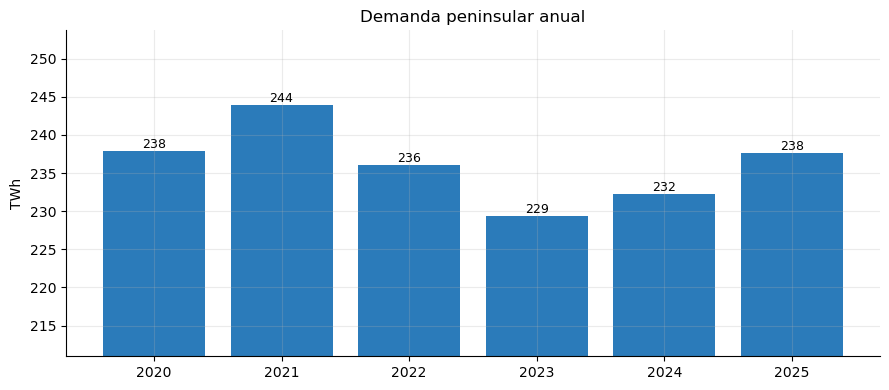

Excluidos por incompletos: [2026] ({2026: 160.1} TWh hasta la fecha de corte).


In [11]:
if dem:
    anual_dem = df.groupby("anio")[dem].sum() / 1e6   # MWh -> TWh
    completos = anual_dem.loc[[a for a in anual_dem.index if a in anios_completos]]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(completos.index.astype(str), completos.values, color="#2b7bba")
    for x, v in zip(completos.index.astype(str), completos.values):
        ax.text(x, v, f"{v:.0f}", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("TWh"); ax.set_title("Demanda peninsular anual")
    ax.set_ylim(completos.min() * 0.92, completos.max() * 1.04)
    plt.tight_layout(); plt.show()

    parciales = [a for a in anual_dem.index if a not in anios_completos]
    if parciales:
        print(f"Excluidos por incompletos: {parciales} "
              f"({anual_dem.loc[parciales].round(1).to_dict()} TWh hasta la fecha de corte).")

## L.6 · Máximos de demanda y perfil diario

**Contexto.** REE distingue el máximo de invierno del de verano. El interés para el TFM es que
**la hora del máximo se está desplazando**: con FV masiva, el pico neto se mueve hacia la
tarde-noche, y ahí es donde se concentran los precios altos.

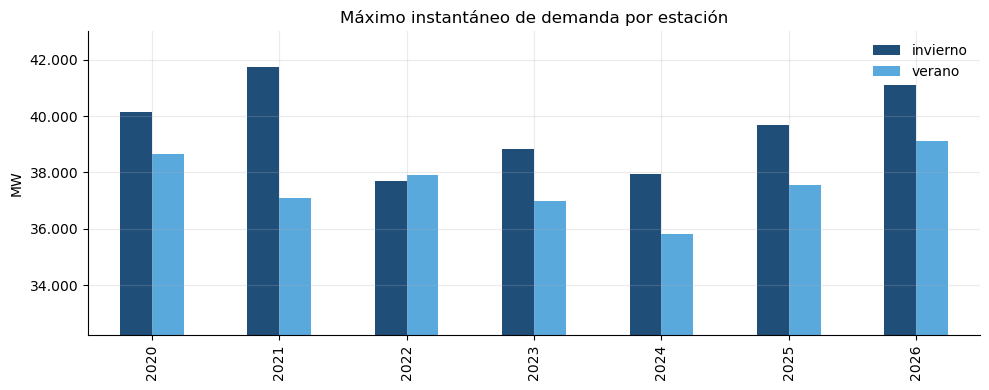

Hora local del máximo diario, moda por año y estación:


estacion,invierno,resto,verano
anio,,,
2020,20,13,13
2021,20,20,13
2022,20,20,14
2023,20,21,14
2024,20,21,21
2025,20,21,21
2026,20,21,20


In [12]:
if dem:
    d2 = df[["ts_local", "anio", "mes", "hora", dem]].dropna().copy()
    d2["estacion"] = np.where(d2["mes"].isin([12, 1, 2]), "invierno",
                      np.where(d2["mes"].isin([6, 7, 8]), "verano", "resto"))

    maximos = (d2[d2["estacion"] != "resto"]
               .groupby(["anio", "estacion"])[dem].max().unstack())
    ax = maximos.plot(kind="bar", figsize=(10, 4), color={"invierno": "#1f4e79", "verano": "#5aa9dd"})
    ax.set_ylabel("MW"); ax.set_xlabel(""); ax.yaxis.set_major_formatter(MILES)
    ax.set_title("Máximo instantáneo de demanda por estación")
    ax.set_ylim(maximos.min().min() * 0.9, maximos.max().max() * 1.03)
    ax.legend(frameon=False)
    plt.tight_layout(); plt.show()

    print("Hora local del máximo diario, moda por año y estación:")
    idx = d2.groupby([d2["ts_local"].dt.date])[dem].idxmax()
    picos = d2.loc[idx]
    display(picos.groupby(["anio", "estacion"])["hora"].agg(lambda s: s.mode().iat[0]).unstack())

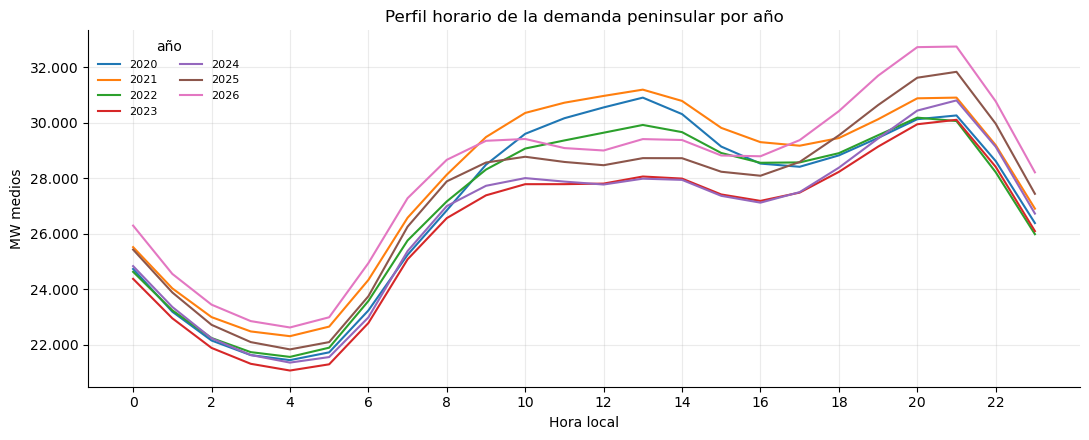

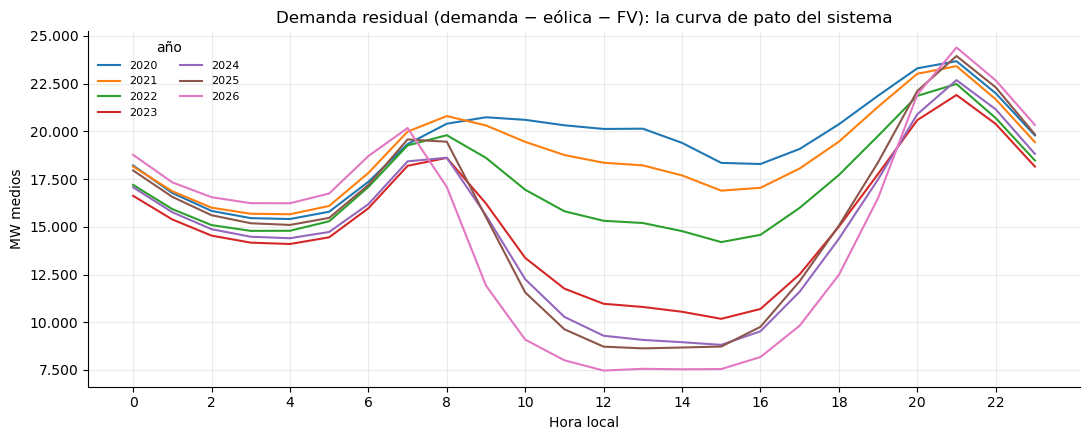

Esta es la figura que explica la forma del precio horario del bloque F.3: el hueco de mediodía se profundiza año a año.


In [13]:
if dem:
    # Perfil horario medio por año: la "descomposición de la demanda" de REE, en versión propia.
    perfil = d2.pivot_table(index="hora", columns="anio", values=dem, aggfunc="mean")
    ax = perfil.plot(figsize=(11, 4.5))
    ax.set_xlabel("Hora local"); ax.set_ylabel("MW medios"); ax.set_xticks(range(0, 24, 2))
    ax.yaxis.set_major_formatter(MILES)
    ax.set_title("Perfil horario de la demanda peninsular por año")
    ax.legend(title="año", frameon=False, ncol=2, fontsize=8)
    plt.tight_layout(); plt.show()

    # Demanda residual: lo que queda por cubrir con tecnologías despachables.
    if eol and fv:
        d3 = df[["hora", "anio", dem, eol, fv]].dropna().copy()
        d3["residual"] = d3[dem] - d3[eol] - d3[fv]
        res = d3.pivot_table(index="hora", columns="anio", values="residual", aggfunc="mean")
        ax = res.plot(figsize=(11, 4.5))
        ax.set_xlabel("Hora local"); ax.set_ylabel("MW medios"); ax.set_xticks(range(0, 24, 2))
        ax.yaxis.set_major_formatter(MILES)
        ax.set_title("Demanda residual (demanda − eólica − FV): la curva de pato del sistema")
        ax.legend(title="año", frameon=False, ncol=2, fontsize=8)
        plt.tight_layout(); plt.show()
        print("Esta es la figura que explica la forma del precio horario del bloque F.3: "
              "el hueco de mediodía se profundiza año a año.")

---
## L.7 · Renovable frente a no renovable

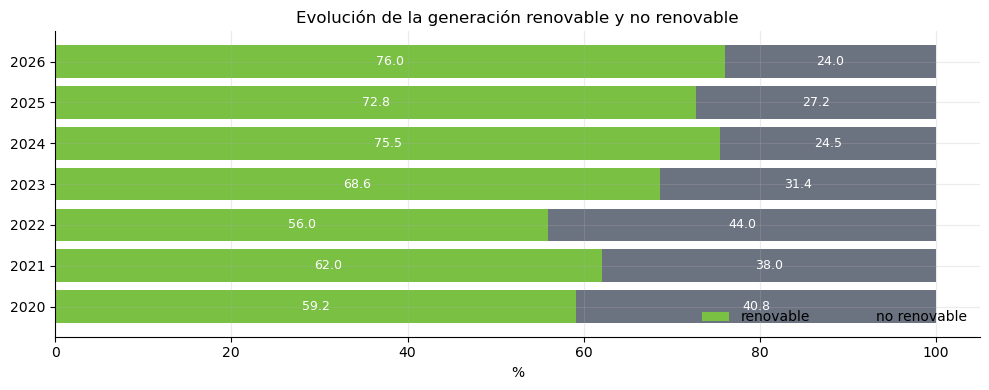

,renovable,no renovable
anio,,
2020,59.2,40.8
2021,62.0,38.0
2022,56.0,44.0
2023,68.6,31.4
2024,75.5,24.5
2025,72.8,27.2
2026,76.0,24.0


In [14]:
fam = pd.DataFrame({
    "renovable": E[[t for t in E.columns if familia(t) == "renovable"]].sum(axis=1),
    "no renovable": E[[t for t in E.columns if familia(t) == "no renovable"]].sum(axis=1),
})
fam_pct = fam.div(fam.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(fam_pct.index.astype(str), fam_pct["renovable"], color="#7ac143", label="renovable")
ax.barh(fam_pct.index.astype(str), fam_pct["no renovable"], left=fam_pct["renovable"],
        color="#6b7280", label="no renovable")
for i, (r, nr) in enumerate(zip(fam_pct["renovable"], fam_pct["no renovable"])):
    ax.text(r / 2, i, f"{r:.1f}", ha="center", va="center", color="white", fontsize=9)
    ax.text(r + nr / 2, i, f"{nr:.1f}", ha="center", va="center", color="white", fontsize=9)
ax.set_xlabel("%"); ax.set_title("Evolución de la generación renovable y no renovable")
ax.legend(frameon=False, ncol=2, loc="lower right")
plt.tight_layout(); plt.show()
display(fam_pct.round(1))

## L.8 · Producción por tecnología, separando renovable y no renovable

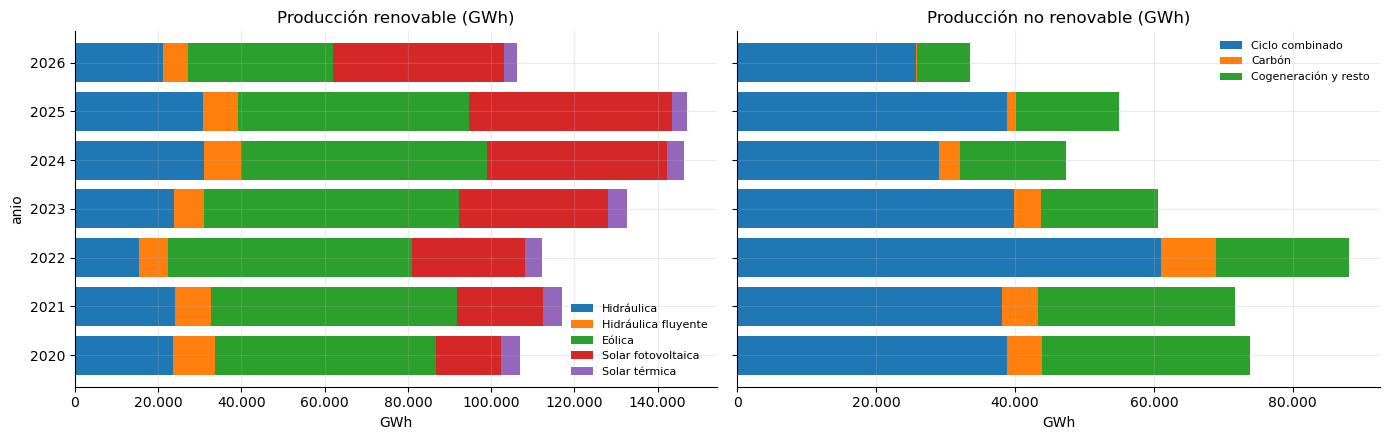

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, f in zip(axes, ["renovable", "no renovable"]):
    sub = E[[t for t in E.columns if familia(t) == f]]
    sub.plot(kind="barh", stacked=True, ax=ax, width=0.8)
    ax.set_title(f"Producción {f} (GWh)"); ax.set_xlabel("GWh")
    ax.xaxis.set_major_formatter(MILES)
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

---
## L.9 · Demanda frente a temperatura: grados-día

**Contexto.** REE descompone el crecimiento de la demanda en laboralidad, temperatura y
actividad económica. Con los datos propios se puede reproducir la parte térmica usando
**grados-día**: la desviación de la temperatura media diaria respecto a un umbral de confort
(18 °C es el estándar), separando frío (HDD, calefacción) de calor (CDD, refrigeración).

**Consecuencia (feature).** La relación demanda-temperatura no es lineal sino en forma de U, y
las dos ramas tienen pendientes distintas. Modelarla como un término lineal en `t2m` desperdicia
justamente la estructura que importa: conviene meter HDD y CDD por separado.

Temperatura convertida de Kelvin a Celsius para esta figura.


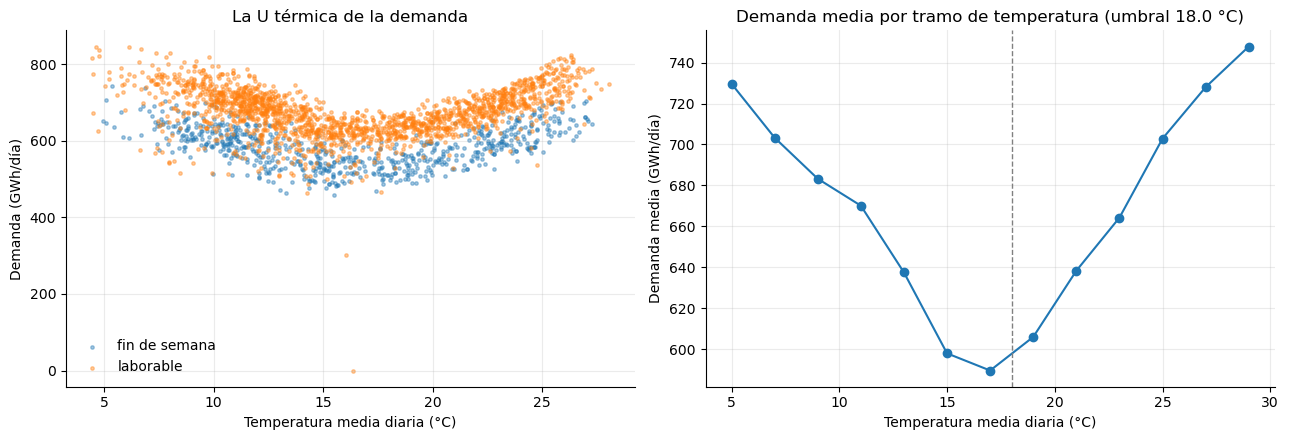

Correlaciones con la demanda (sólo días laborables, para quitar el efecto calendario):
  temperatura lineal : +0.0109   <- baja, y por eso engaña
  grados-día de frío : +0.2292
  grados-día de calor: +0.3371

Si la correlación lineal es débil pero HDD y CDD son fuertes, queda demostrado que la temperatura entra al modelo partida en dos ramas, no como un término lineal.


In [16]:
t2m = pick(df, "era5_t2m_mean")
if not (t2m and dem):
    OMITIDOS.append("L.9: falta era5_t2m_mean o la demanda")
    print("OMITIDO --", {"t2m": t2m, "demanda": dem})
else:
    dia = df.groupby("dia").agg(temp=(t2m, "mean"), demanda=(dem, "sum")).dropna()
    # ERA5 viene en Kelvin (el bronce no convierte: eso es silver). Se detecta por el rango.
    if dia["temp"].mean() > 200:
        dia["temp"] = dia["temp"] - 273.15
        print("Temperatura convertida de Kelvin a Celsius para esta figura.")
    dia["demanda"] = dia["demanda"] / 1000          # GWh/día
    dia.index = pd.to_datetime(dia.index)
    dia["anio"] = dia.index.year
    dia["laborable"] = dia.index.dayofweek < 5

    UMBRAL = 18.0
    dia["HDD"] = (UMBRAL - dia["temp"]).clip(lower=0)
    dia["CDD"] = (dia["temp"] - UMBRAL).clip(lower=0)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for lab, sub in dia.groupby("laborable"):
        axes[0].scatter(sub["temp"], sub["demanda"], s=6, alpha=0.4,
                        label="laborable" if lab else "fin de semana")
    axes[0].set_xlabel("Temperatura media diaria (°C)"); axes[0].set_ylabel("Demanda (GWh/día)")
    axes[0].set_title("La U térmica de la demanda"); axes[0].legend(frameon=False)

    binned = dia.groupby(pd.cut(dia["temp"], bins=np.arange(-2, 34, 2)), observed=True)["demanda"].mean()
    axes[1].plot([i.mid for i in binned.index], binned.values, marker="o")
    axes[1].axvline(UMBRAL, color="grey", ls="--", lw=1)
    axes[1].set_xlabel("Temperatura media diaria (°C)"); axes[1].set_ylabel("Demanda media (GWh/día)")
    axes[1].set_title(f"Demanda media por tramo de temperatura (umbral {UMBRAL} °C)")
    plt.tight_layout(); plt.show()

    lab = dia[dia["laborable"]]
    print("Correlaciones con la demanda (sólo días laborables, para quitar el efecto calendario):")
    print(f"  temperatura lineal : {lab['temp'].corr(lab['demanda']):+.4f}   <- baja, y por eso engaña")
    print(f"  grados-día de frío : {lab['HDD'].corr(lab['demanda']):+.4f}")
    print(f"  grados-día de calor: {lab['CDD'].corr(lab['demanda']):+.4f}")
    print("\nSi la correlación lineal es débil pero HDD y CDD son fuertes, queda demostrado que "
          "la temperatura entra al modelo partida en dos ramas, no como un término lineal.")

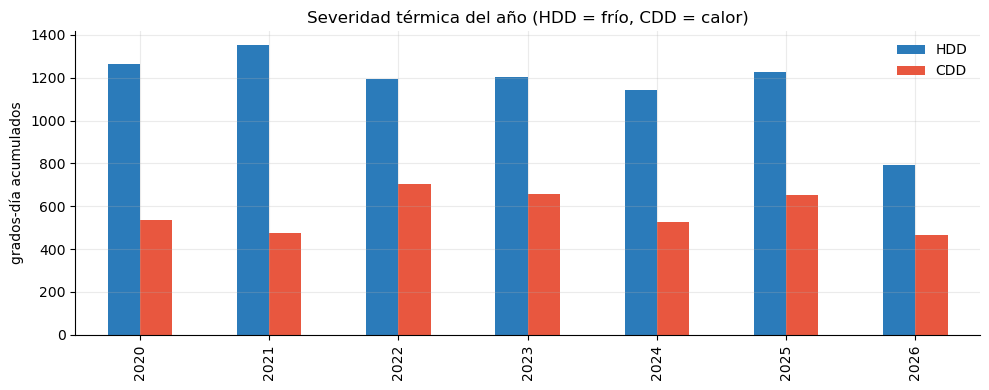

,HDD,CDD
anio,,
2020,1263.0,534.0
2021,1352.0,477.0
2022,1195.0,706.0
2023,1206.0,659.0
2024,1143.0,527.0
2025,1229.0,653.0
2026,792.0,465.0


Comparar años sin corregir por severidad térmica mezcla el efecto del clima con el de la actividad. Los años parciales no son comparables aquí.


In [17]:
if t2m and dem:
    # Grados-día por año: la parte "temperatura" de la descomposición de REE.
    gd = dia.groupby("anio")[["HDD", "CDD"]].sum()
    ax = gd.plot(kind="bar", figsize=(10, 4), color={"HDD": "#2b7bba", "CDD": "#e8573f"})
    ax.set_ylabel("grados-día acumulados"); ax.set_xlabel("")
    ax.set_title("Severidad térmica del año (HDD = frío, CDD = calor)")
    ax.legend(frameon=False)
    plt.tight_layout(); plt.show()
    display(gd.round(0))
    print("Comparar años sin corregir por severidad térmica mezcla el efecto del clima con el "
          "de la actividad. Los años parciales no son comparables aquí.")

---
## L.10 · Hidráulica: estacionalidad y años secos

**Contexto.** La hidráulica de embalse es la tecnología con más margen de decisión del
operador: se guarda agua cuando el precio es bajo y se turbina cuando es alto. Su
estacionalidad no es solo climática, es también estratégica.

**Consecuencia.** Un año seco cambia el orden de mérito de todo el sistema. Si el período de
entrenamiento incluye un año hidrológicamente atípico, conviene saberlo antes de interpretar
los errores del modelo en ese tramo.

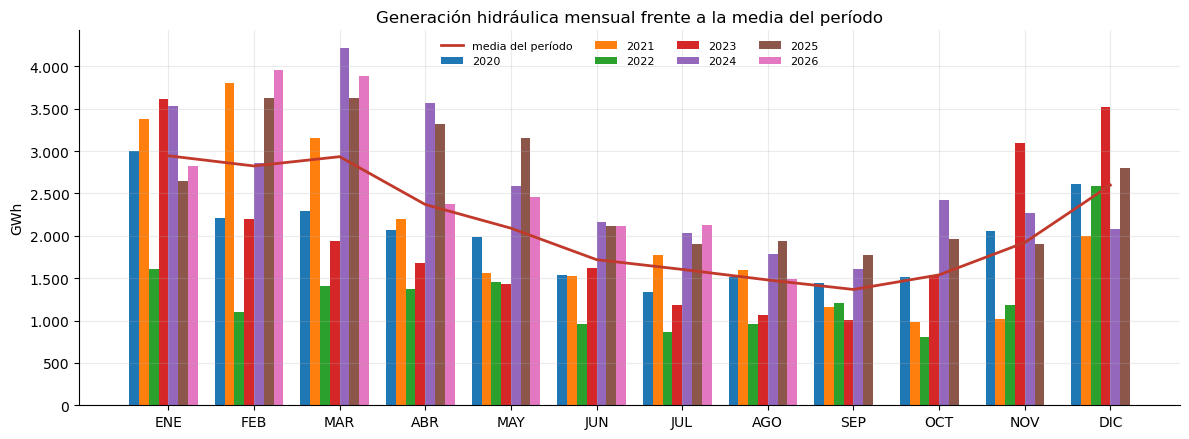

,GWh,desviación % sobre la media
anio,,
2020,23593.0,-5.1
2021,24152.0,-2.8
2022,15520.0,-37.5
2023,23902.0,-3.8
2024,31129.0,25.3
2025,30799.0,23.9
2026,21232.0,-14.6


In [18]:
hid = COLS.get("Hidráulica")
if not hid:
    OMITIDOS.append("L.10: sin columna de hidráulica")
    print("OMITIDO -- sin columna de hidráulica")
else:
    h = df.groupby(["anio", "mes"])[hid].sum().unstack() / 1000     # GWh
    media_mes = h.mean()

    fig, ax = plt.subplots(figsize=(12, 4.5))
    x = np.arange(1, 13)
    ancho = 0.8 / len(h)
    for i, (anio, fila) in enumerate(h.iterrows()):
        ax.bar(x + i * ancho - 0.4, fila.values, width=ancho, label=str(anio))
    ax.plot(x, media_mes.values, color="#c0392b", lw=2, label="media del período")
    ax.set_xticks(x, ["ENE","FEB","MAR","ABR","MAY","JUN","JUL","AGO","SEP","OCT","NOV","DIC"])
    ax.set_ylabel("GWh"); ax.yaxis.set_major_formatter(MILES)
    ax.set_title("Generación hidráulica mensual frente a la media del período")
    ax.legend(frameon=False, ncol=4, fontsize=8)
    plt.tight_layout(); plt.show()

    anual_h = h.sum(axis=1)
    desv = ((anual_h / anual_h[anual_h.index.isin(anios_completos)].mean() - 1) * 100).round(1)
    display(pd.DataFrame({"GWh": anual_h.round(0), "desviación % sobre la media": desv}))

---
## L.11 · Coeficiente de utilización de las térmicas

**Contexto.** Producción real dividida entre producción máxima posible con la potencia
disponible. En el informe de REE separa nuclear (que va a plena carga siempre), carbón y ciclo
combinado.

**Consecuencia.** El coeficiente del ciclo combinado es un termómetro directo de la tensión del
sistema: sube cuando la renovable no cubre y el precio se dispara. Ojo con la fuente de
capacidad: `cap_disp_*` arrastra el problema de D-01 (el valor guardado es el conocido *a
posteriori*), así que esta figura es descriptiva, no una feature.

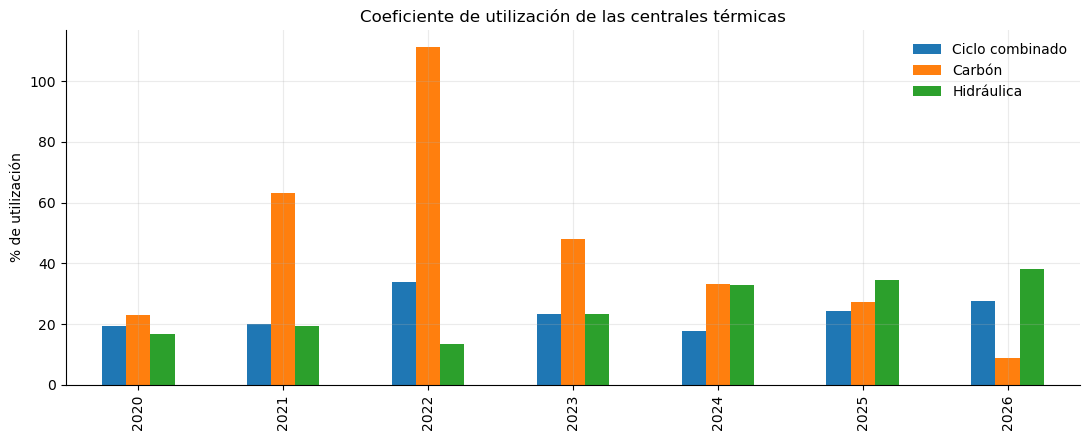

,Ciclo combinado,Carbón,Hidráulica
anio,,,
2020,19.2,22.9,16.7
2021,19.8,63.2,19.2
2022,33.7,111.1,13.3
2023,23.4,47.8,23.2
2024,17.9,33.3,32.8
2025,24.2,27.3,34.4
2026,27.6,8.8,38.3


Recordatorio: cap_disp_* tiene el problema de D-01 (valor conocido a posteriori). Vale para describir, no como feature.


In [19]:
PARES_UTIL = {
    "Nuclear": ("Nuclear", "cap_disp_nuclear_mw"),
    "Ciclo combinado": ("Ciclo combinado", "cap_disp_ccgt_mw"),
    "Carbón": ("Carbón", "cap_disp_coal_antracita_mw"),
    "Hidráulica": ("Hidráulica", "cap_disp_hydro_mw"),
}
filas = []
for etiq, (tec, cap) in PARES_UTIL.items():
    col_gen, col_cap = COLS.get(tec), pick(df, cap)
    if not (col_gen and col_cap):
        continue
    sub = df[["anio", col_gen, col_cap]].dropna()
    u = sub.groupby("anio").apply(
        lambda g: g[col_gen].sum() / g[col_cap].sum() * 100, include_groups=False)
    filas.append(u.rename(etiq))

if filas:
    util = pd.concat(filas, axis=1)
    ax = util.plot(kind="bar", figsize=(11, 4.5))
    ax.set_ylabel("% de utilización"); ax.set_xlabel("")
    ax.set_title("Coeficiente de utilización de las centrales térmicas")
    ax.legend(frameon=False)
    plt.tight_layout(); plt.show()
    display(util.round(1))
    print("Recordatorio: cap_disp_* tiene el problema de D-01 (valor conocido a posteriori). "
          "Vale para describir, no como feature.")
else:
    OMITIDOS.append("L.11: faltan las columnas cap_disp_*")
    print("OMITIDO -- faltan cap_disp_*. Requiere esios_capacity_available en el bronce.")

---
## L.12 · Precio frente a commodities

**Contexto.** Durante buena parte del período el ciclo combinado marca el precio marginal, así
que el precio eléctrico debería seguir al gas con un factor próximo al rendimiento de la
central. La excepción ibérica rompe esa relación por diseño.

**Consecuencia (feature).** Es la única de estas figuras cuyos insumos están disponibles a las
12:00 de D — con desfase, porque TTF y EUA cierran a las 17:30 y el último dato utilizable es
el de D−2. El *clean spark spread* implícito que se calcula aquí es una feature candidata real.

C:\Users\torgi\AppData\Local\Temp\ipykernel_16072\1355457792.py:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  c["mes_p"] = c["ts_local"].dt.to_period("M")


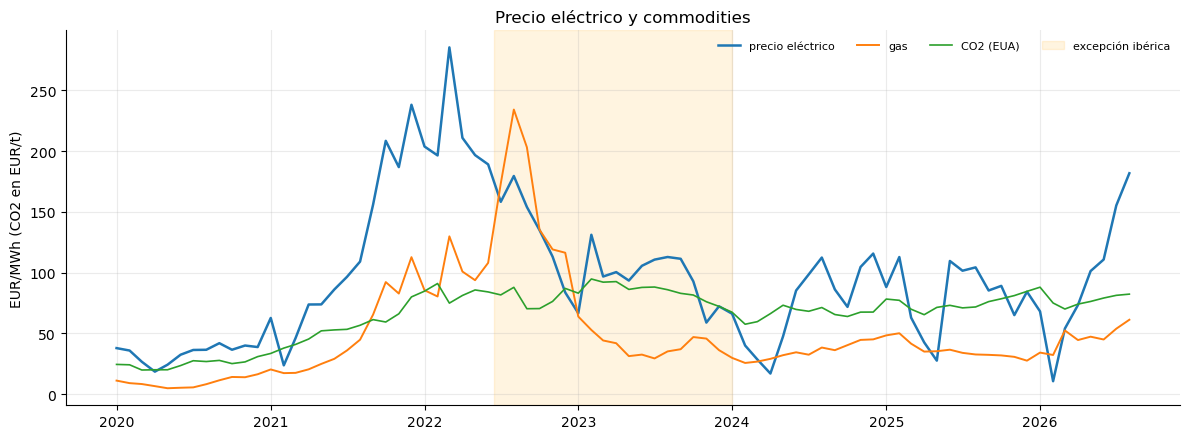

ratio                                          
                  count  mean   std   min   25%   50%   75%   max
regimen                                                          
excepción ibérica  18.0  1.93  1.02  0.72  0.96  1.99  2.86  3.76
normal             62.0  2.54  1.09  0.33  2.09  2.44  2.97  6.49

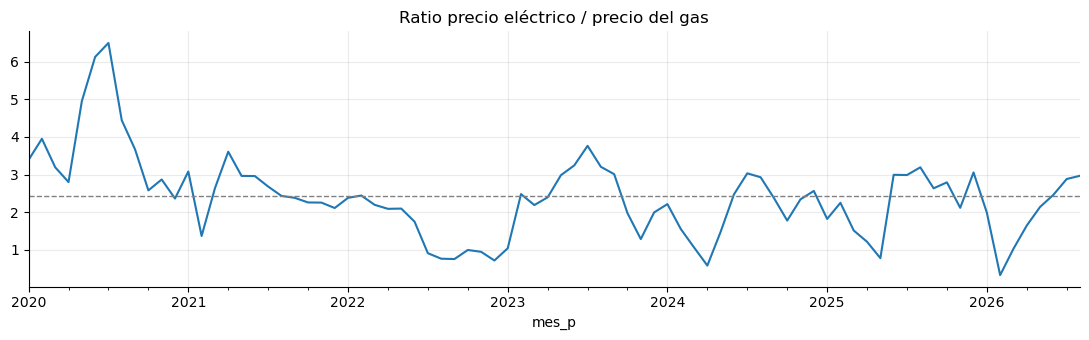

Un ratio estable en régimen normal y hundido durante la excepción confirma que el tope al gas desacopló las dos series: son dos regímenes, no ruido.


In [20]:
spot = pick(df, "spot_es_omie", "es_omie", "spot_es_esios", "spot_es_entsoe")
gas = pick(df, "tp_ttf_cierre", "commodities_gas_ttf_m1", "commodities_gas_mibgas")
co2 = pick(df, "tp_eua_cierre", "commodities_co2_eua_dec")

if not spot:
    OMITIDOS.append("L.12: spot_price no está en el bronce todavía")
    print("OMITIDO -- falta el precio. Es el hueco nº 1 del EDA: añadir spot_price al bronce.")
elif not gas:
    OMITIDOS.append("L.12: sin columna de gas")
    print("OMITIDO -- sin columna de gas")
else:
    c = df[["ts_local", "anio", spot, gas] + ([co2] if co2 else [])].dropna(subset=[gas]).copy()
    c["mes_p"] = c["ts_local"].dt.to_period("M")
    mensual = c.groupby("mes_p").agg({spot: "mean", gas: "mean", **({co2: "mean"} if co2 else {})})

    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.plot(mensual.index.to_timestamp(), mensual[spot], label="precio eléctrico", lw=1.8)
    ax.plot(mensual.index.to_timestamp(), mensual[gas], label="gas", lw=1.4)
    if co2:
        ax.plot(mensual.index.to_timestamp(), mensual[co2], label="CO2 (EUA)", lw=1.2)
    ax.axvspan(EXCEPCION[0].tz_localize(None), EXCEPCION[1].tz_localize(None),
               alpha=0.12, color="orange", label="excepción ibérica")
    ax.set_ylabel("EUR/MWh (CO2 en EUR/t)")
    ax.set_title("Precio eléctrico y commodities")
    ax.legend(frameon=False, ncol=4, fontsize=8)
    plt.tight_layout(); plt.show()

    # Ratio implícito: cuántos EUR de electricidad por cada EUR de gas.
    mensual["ratio"] = mensual[spot] / mensual[gas].replace(0, np.nan)
    mensual["regimen"] = np.where(
        (mensual.index.to_timestamp() >= EXCEPCION[0].tz_localize(None)) &
        (mensual.index.to_timestamp() <= EXCEPCION[1].tz_localize(None)),
        "excepción ibérica", "normal")
    display(mensual.groupby("regimen")[["ratio"]].describe().round(2))

    ax = mensual["ratio"].plot(figsize=(11, 3.5), title="Ratio precio eléctrico / precio del gas")
    ax.axhline(mensual.loc[mensual["regimen"] == "normal", "ratio"].median(),
               color="grey", ls="--", lw=1)
    plt.tight_layout(); plt.show()
    print("Un ratio estable en régimen normal y hundido durante la excepción confirma que el "
          "tope al gas desacopló las dos series: son dos regímenes, no ruido.")

C:\Users\torgi\AppData\Local\Temp\ipykernel_16072\174223190.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  s["mes_p"] = s["ts_local"].dt.to_period("M")


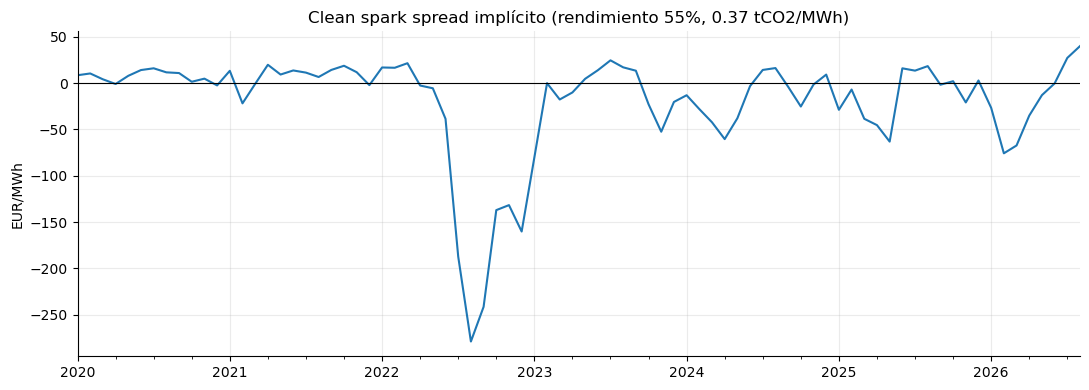

Cuando el spread es negativo, el CCGT no cubre costes: o no está marcando el precio, o los parámetros asumidos no describen bien el parque. Ambas conclusiones son útiles.


In [21]:
# Clean spark spread implícito: margen del ciclo combinado por MWh eléctrico.
# Rendimiento típico de un CCGT moderno: ~55%. Factor de emisión: ~0,37 tCO2/MWh eléctrico.
if spot and gas:
    RENDIMIENTO, EMISION = 0.55, 0.37
    s = df[["ts_local", spot, gas] + ([co2] if co2 else [])].dropna(subset=[spot, gas]).copy()
    coste_gas = s[gas] / RENDIMIENTO
    coste_co2 = s[co2] * EMISION if co2 else 0
    s["spark"] = s[spot] - coste_gas - coste_co2
    s["mes_p"] = s["ts_local"].dt.to_period("M")

    ax = s.groupby("mes_p")["spark"].mean().plot(figsize=(11, 4))
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel("EUR/MWh"); ax.set_xlabel("")
    ax.set_title(f"Clean spark spread implícito (rendimiento {RENDIMIENTO:.0%}, "
                 f"{EMISION} tCO2/MWh)")
    plt.tight_layout(); plt.show()
    print("Cuando el spread es negativo, el CCGT no cubre costes: o no está marcando el precio, "
          "o los parámetros asumidos no describen bien el parque. Ambas conclusiones son útiles.")

---
## L.13 · Interconexiones

**Contexto.** El saldo con Francia y Portugal es una válvula del sistema: en horas de excedente
renovable España exporta, y en horas de escasez importa. Cuando la interconexión se satura, el
precio se desacopla del país vecino.

**Consecuencia.** Explica por qué el precio francés correlaciona tanto con el español y por qué,
aun así, **no puede usarse como feature**: ambos se casan a la vez a las 12:00, así que el de
D+1 no existe cuando hay que predecir.

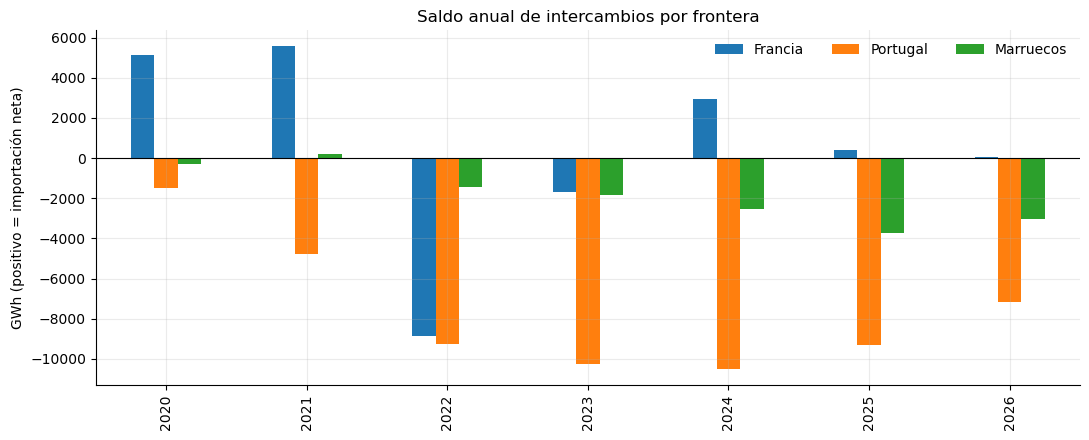

,Francia,Portugal,Marruecos
anio,,,
2020,5149.0,-1498.0,-295.0
2021,5560.0,-4776.0,183.0
2022,-8845.0,-9261.0,-1435.0
2023,-1695.0,-10252.0,-1858.0
2024,2942.0,-10488.0,-2541.0
2025,400.0,-9303.0,-3753.0
2026,78.0,-7154.0,-3043.0


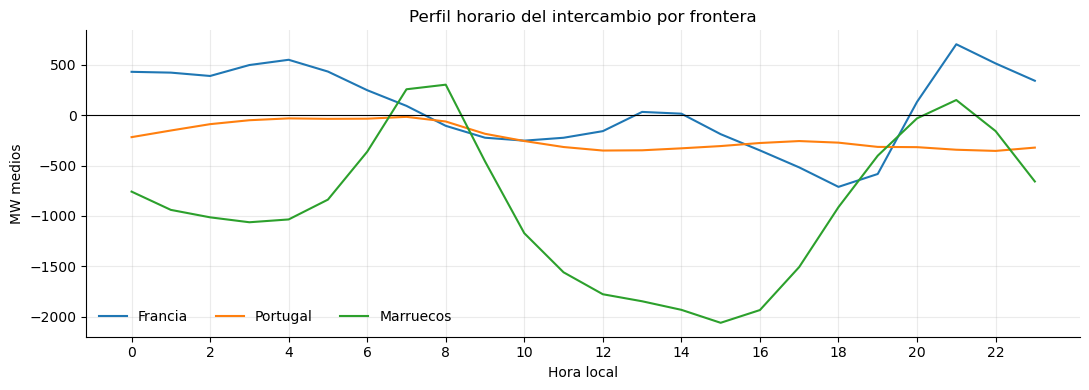

Si la exportación se concentra en las horas centrales, es el excedente fotovoltaico saliendo por la interconexión -- el mismo fenómeno que hunde el precio a mediodía.


In [22]:
cols_inter = {p: pick(df, *c) for p, c in FRONTERAS.items()}
cols_inter = {p: c for p, c in cols_inter.items() if c}
if not cols_inter:
    OMITIDOS.append("L.13: sin columnas de interconexión")
    print("OMITIDO -- sin columnas de interconexión reconocidas")
else:
    inter = df.groupby("anio")[list(cols_inter.values())].sum() / 1000
    inter.columns = list(cols_inter.keys())
    ax = inter.plot(kind="bar", figsize=(11, 4.5))
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel("GWh (positivo = importación neta)"); ax.set_xlabel("")
    ax.set_title("Saldo anual de intercambios por frontera")
    ax.legend(frameon=False, ncol=4)
    plt.tight_layout(); plt.show()
    display(inter.round(0))

    # Perfil horario: ¿cuándo se exporta?
    perfil_i = df.pivot_table(index="hora", values=list(cols_inter.values()), aggfunc="mean")
    perfil_i.columns = list(cols_inter.keys())
    ax = perfil_i.plot(figsize=(11, 4))
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xlabel("Hora local"); ax.set_ylabel("MW medios"); ax.set_xticks(range(0, 24, 2))
    ax.set_title("Perfil horario del intercambio por frontera")
    ax.legend(frameon=False, ncol=4)
    plt.tight_layout(); plt.show()
    print("Si la exportación se concentra en las horas centrales, es el excedente fotovoltaico "
          "saliendo por la interconexión -- el mismo fenómeno que hunde el precio a mediodía.")

---
## Cierre

In [23]:
print("BLOQUES OMITIDOS")
print("=" * 60)
if OMITIDOS:
    for o in dict.fromkeys(OMITIDOS):
        print(" -", o)
    print("\nCada línea es una figura que no se pudo construir. O se resuelve la dependencia, "
          "o la figura no entra en la memoria: lo que no vale es una figura a medias.")
else:
    print("Ninguno: el notebook corrió completo.")

print("\n\nFIGURAS CANDIDATAS PARA LA MEMORIA")
print("=" * 60)
for linea in [
    "Trece figuras son demasiadas para un capítulo. Propuesta de cuatro, cada una atada a",
    "algo que el resto del TFM necesita:",
    "",
    "  L.4  Cobertura de la demanda por eólica y FV  -> justifica el cambio estructural del precio",
    "  L.6  Demanda residual por hora y año          -> explica la forma horaria que el modelo aprende",
    "  L.9  La U térmica de la demanda               -> justifica meter HDD y CDD, no temperatura lineal",
    "  L.12 Precio frente a commodities              -> justifica tratar la excepción ibérica aparte",
    "",
    "El resto queda en el notebook y se cita. Un capítulo de EDA no es una galería: cada",
    "figura tiene que responder a una pregunta que se plantea en otro sitio de la memoria.",
]:
    print(linea)

BLOQUES OMITIDOS
 - tecnologías sin resolver: ['Biomasa', 'Residuos', 'Otras renovables', 'Nuclear', 'Fuel / gasoil']

Cada línea es una figura que no se pudo construir. O se resuelve la dependencia, o la figura no entra en la memoria: lo que no vale es una figura a medias.


FIGURAS CANDIDATAS PARA LA MEMORIA
Trece figuras son demasiadas para un capítulo. Propuesta de cuatro, cada una atada a
algo que el resto del TFM necesita:

  L.4  Cobertura de la demanda por eólica y FV  -> justifica el cambio estructural del precio
  L.6  Demanda residual por hora y año          -> explica la forma horaria que el modelo aprende
  L.9  La U térmica de la demanda               -> justifica meter HDD y CDD, no temperatura lineal
  L.12 Precio frente a commodities              -> justifica tratar la excepción ibérica aparte

El resto queda en el notebook y se cita. Un capítulo de EDA no es una galería: cada
figura tiene que responder a una pregunta que se plantea en otro sitio de la memoria.
